## Single Node 

Current State: {'message': 'user_input'}
{'message': 'user_input World!'}


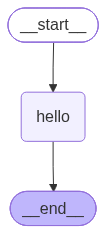

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


# ------------------------
# State
# ------------------------
class State(TypedDict):
    message: str


# ------------------------
# Node
# ------------------------
def hello_node(state: State):
    print("Current State:", state)

    return {
        "message": state["message"] + " World!"
    }


# ------------------------
# Graph
# ------------------------
builder = StateGraph(State)

builder.add_node("hello", hello_node)

builder.add_edge(START, "hello")
builder.add_edge("hello", END)

graph = builder.compile()


# ------------------------
# Execute
# ------------------------

result = graph.invoke(
    {
        "message": "user_input"
    }
)

print(result)
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

## Multiple Node 

Add One
Multiply Two
{'number': 12}


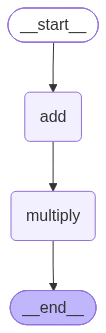

In [15]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    number: int

# number =5
def add_one(state: State):
    print("Add One")
    return {
        "number": state["number"] + 1
    }

# number 5+1 =6
def multiply_two(state: State):
    print("Multiply Two")
    return {
        "number": state["number"] * 2
    }
# number 6*2 =12

builder = StateGraph(State)

builder.add_node("add", add_one)
builder.add_node("multiply", multiply_two)

builder.add_edge(START, "add")
builder.add_edge("add", "multiply")
builder.add_edge("multiply", END)

graph = builder.compile()

result = graph.invoke(
    {
        "number": 5
    }
)

print(result)
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

## Conditional Edge

Odd Number


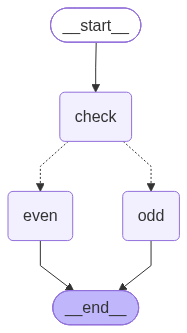

In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    number: int


def check_number(state: State):
    return state


def even_node(state: State):
    print("Even Number")
    return state


def odd_node(state: State):
    print("Odd Number")
    return state


def router(state: State):

    if state["number"] % 2 == 0:
        return "even"

    return "odd"


builder = StateGraph(State)

builder.add_node("check", check_number)
builder.add_node("even", even_node)
builder.add_node("odd", odd_node)

builder.add_edge(START, "check")

builder.add_conditional_edges(
    "check",
    router,
    {
        "even": "even",
        "odd": "odd"
    }
)

builder.add_edge("even", END)
builder.add_edge("odd", END)

graph = builder.compile()

graph.invoke({"number": 11})
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

## Loop Until Condition is Met

Count: 1
Count: 2
Count: 3
Count: 4


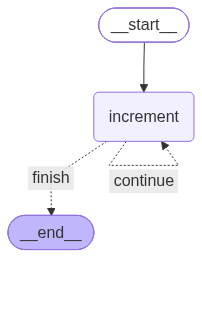

In [8]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    count: int


def increment(state: State):
    print("Count:", state["count"])
    return {"count": state["count"] + 1}


def router(state: State):
    if state["count"] >= 5:
        return "finish"
    return "continue"


builder = StateGraph(State)

builder.add_node("increment", increment)

builder.add_edge(START, "increment")

builder.add_conditional_edges(
    "increment",
    router,
    {
        "continue": "increment",
        "finish": END,
    },
)

graph = builder.compile()

graph.invoke({"count": 1})

from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

## Basic LLM Node 

{'question': 'What is OPC UA?', 'answer': "OPC Unified Architecture (OPC UA) is a communication protocol used for industrial automation and IoT applications. It allows devices, systems, and software to communicate with each other in a standardized way.\n\nHere's what makes OPC UA special:\n\n**Key features:**\n\n1. **Platform independence**: OPC UA can run on any platform, including Windows, Linux, macOS, and others.\n2. **Device-agnostic**: Devices from different manufacturers can use the same protocol to communicate with each other.\n3. **Security**: OPC UA has built-in security features, such as encryption, authentication, and access control.\n4. **Data modeling**: OPC UA uses a standardized data model to represent industrial data, making it easier for devices and systems to understand each other.\n\n**How it works:**\n\n1. A device or system (e.g., a programmable logic controller (PLC)) exposes its data and functionality through an OPC UA server.\n2. Other devices or systems can co

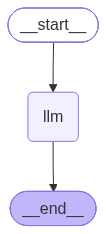

In [10]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama


# ----------------------------
# LLM
# ----------------------------
llm = ChatOllama(
    model="llama3.1:8b",
    base_url="http://localhost:11434",
    temperature=0,
)


# ----------------------------
# State
# ----------------------------
class State(TypedDict):
    question: str
    answer: str


# ----------------------------
# LLM Node
# ----------------------------
def llm_node(state: State):

    response = llm.invoke(state["question"])

    return {
        "answer": response.content
    }


# ----------------------------
# Graph
# ----------------------------
builder = StateGraph(State)

builder.add_node("llm", llm_node)

builder.add_edge(START, "llm")
builder.add_edge("llm", END)

graph = builder.compile()


# ----------------------------
# Execute
# ----------------------------
result = graph.invoke(
    {
        "question": "What is OPC UA?",
        "answer": ""
    }
)

print(result)

from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
from langchain_core.tools import tool
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.1:8b",
    temperature=0,
)


@tool
def add(a: int, b: int) -> int:
    """Add two numbers."""
    return a + b

tools = [add]

llm_with_tools = llm.bind_tools(tools)



from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]



def chatbot(state: State):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools)

from langgraph.prebuilt import tools_condition

from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("chatbot", chatbot)
builder.add_node("tools", tool_node)

builder.add_edge(START, "chatbot")

builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

builder.add_edge("tools", "chatbot")

graph = builder.compile()

from langchain_core.messages import HumanMessage

response = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="Add 50 and 60"
            )
        ]
    }
)

print(response["messages"][-1].content)


try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

c:\RAG_POC\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The result of adding 50 and 60 is 110.


## Memory With CheckPoint

In [3]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from langgraph.checkpoint.memory import MemorySaver

from langchain_core.messages import HumanMessage
from langchain_ollama import ChatOllama


llm = ChatOllama(model="llama3.1:8b")


class State(TypedDict):
    messages: Annotated[list, add_messages]


def chatbot(state: State):

    response = llm.invoke(state["messages"])

    return {
        "messages": [response]
    }


builder = StateGraph(State)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

memory = MemorySaver()

graph = builder.compile(
    checkpointer=memory
)


config = {
    "configurable": {
        "thread_id": "abc123"
    }
}

In [4]:
graph.invoke(
    {
        "messages":[
            HumanMessage(content="My name is Kishor.")
        ]
    },
    config=config
)

{'messages': [HumanMessage(content='My name is Kishor.', additional_kwargs={}, response_metadata={}, id='c7597493-0e85-4592-a613-d9aada8f0e5e'),
  AIMessage(content='Nice to meet you, Kishor! Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-07-22T08:43:56.252073584Z', 'done': True, 'done_reason': 'stop', 'total_duration': 837504399, 'load_duration': 89298493, 'prompt_eval_count': 17, 'prompt_eval_duration': 246687800, 'eval_count': 25, 'eval_duration': 480424888, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019f88fe-ea92-7f11-95be-c70f2e82ed38-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 25, 'total_tokens': 42})]}

In [5]:
result = graph.invoke(
    {
        "messages":[
            HumanMessage(content="What is my name?")
        ]
    },
    config=config
)

print(result["messages"][-1].content)

Your name is Kishor.


## Human-in-the-loop (interrupt())

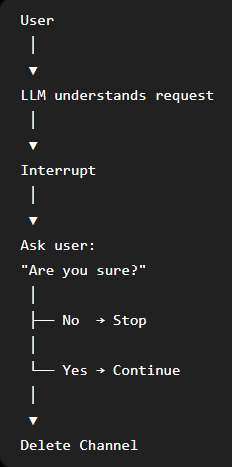

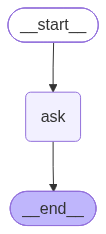

In [21]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt


class State(TypedDict):
    name: str


def ask_name(state: State):

    user_input = input(
        "Please enter your name"
    )

    return {
        "name": user_input
    }


builder = StateGraph(State)

builder.add_node("ask", ask_name)

builder.add_edge(START, "ask")
builder.add_edge("ask", END)

graph = builder.compile(
    checkpointer=MemorySaver()
)
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [ ]:
config = {
    "configurable": {
        "thread_id": "123"
    }
}

result = graph.invoke(
    {},
    config=config
)

print(result)

In [1]:
from langgraph.types import Command

result = graph.invoke(
    Command(resume="Kishor"),
    config=config
)

print(result)

NameError: name 'graph' is not defined

In [41]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from IPython.display import display, HTML
from IPython import get_ipython

# ----------------------------
# Graph State
# ----------------------------
class State(TypedDict):
    channel: str
    action: str
    status: str

# ----------------------------
# Node
# ----------------------------
def approval_node(state: State):

    decision = interrupt(
        f"""
Pending Request

Action : {state['action']}
Channel: {state['channel']}
"""
    )

    if decision["action"] == "approve":

        return {
            "status": f"✅ {state['action']} executed for {state['channel']}"
        }

    elif decision["action"] == "reject":

        return {
            "status": "❌ Operation Cancelled"
        }

    elif decision["action"] == "modify":

        return {
            "channel": decision["channel"],
            "status": f"✅ Modified channel to {decision['channel']}"
        }


# ----------------------------
# Build Graph
# ----------------------------
builder = StateGraph(State)

builder.add_node("approval", approval_node)

builder.add_edge(START, "approval")
builder.add_edge("approval", END)

graph = builder.compile(
    checkpointer=MemorySaver()
)

config = {
    "configurable": {
        "thread_id": "demo-thread"
    }
}

# ----------------------------
# Start Graph
# ----------------------------
result = graph.invoke(
    {
        "channel": "Channel1",
        "action": "Delete",
        "status": ""
    },
    config=config
)

print(result["__interrupt__"][0].value)

# ----------------------------
# Resume Function
# ----------------------------
def resume_graph(action, channel=None):

    data = {"action": action}

    if channel:
        data["channel"] = channel

    result = graph.invoke(
        Command(resume=data),
        config=config
    )

    print("\nFinal State")
    print(result)

# Make function visible to Javascript
ip = get_ipython()
ip.push({"resume_graph": resume_graph})

# ----------------------------
# HTML UI
# ----------------------------
display(HTML("""

<h2>Human Approval</h2>

<button onclick="
IPython.notebook.kernel.execute(
'resume_graph(\\'approve\\')'
)
">
✅ Approve
</button>

<button onclick="
IPython.notebook.kernel.execute(
'resume_graph(\\'reject\\')'
)
">
❌ Reject
</button>

<br><br>

<input id="channel" placeholder="New Channel Name">

<button onclick="
var name=document.getElementById('channel').value;
IPython.notebook.kernel.execute(
'resume_graph(\\'modify\\',\\''+name+'\\')'
)
">
✏️ Modify
</button>

"""))


Pending Request

Action : Delete
Channel: Channel1



## MCP tool integration

In [1]:
# Connect with the mcp server
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient(
    {
        "kepware": {
            "transport": "streamable_http",
            "url": "http://localhost:8000/mcp"
        }
    }
)

In [ ]:
# Load the mcp tool 
from NewClient_MCP import get_mcp_tools

tools

async def client_mcp(message: str): 
    
    tools = await get_mcp_tools()
    print("Available Tools:")
    for tool in tools:
        print("-", tool.name)
mcp_tools = await get_mcp_tools()

ModuleNotFoundError: No module named 'NewClient_MCP'

In [45]:
# Bind the tool 
llm_with_tools = llm.bind_tools(mcp_tools)

TypeError: 'coroutine' object is not iterable

In [ ]:
# ChatBot node
def chatbot(state):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

In [ ]:
# Tool Node 
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(mcp_tools)

In [9]:
# Graph 
builder.add_node("chatbot", chatbot)
builder.add_node("tools", tool_node)

builder.add_edge(START, "chatbot")

builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

builder.add_edge("tools", "chatbot")

NameError: name 'builder' is not defined

## React Agent 

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langchain_ollama import ChatOllama


# ======================================================
# Step 1 : Create a Tool
# ======================================================

@tool
def calculator(a: int, b: int) -> int:
    """Add two numbers."""
    print(f"\n[TOOL] calculator({a}, {b})")

    return a + b


tools = [calculator]


# ======================================================
# Step 2 : LLM
# ======================================================

llm = ChatOllama(
    model="llama3.1:8b",
    temperature=0
)

llm_with_tools = llm.bind_tools(tools)


# ======================================================
# Step 3 : Graph State
# ======================================================

class State(TypedDict):
    messages: Annotated[list, add_messages]


# ======================================================
# Step 4 : Chatbot Node
# ======================================================

def chatbot(state: State):

    print("\n========== CHATBOT ==========")

    print("\nMessages received:")

    for msg in state["messages"]:
        print(type(msg).__name__, ":", msg.content)

    response = llm_with_tools.invoke(state["messages"])

    print("\nLLM Response:")

    print(response)

    return {
        "messages": [response]
    }


# ======================================================
# Step 5 : Tool Node
# ======================================================

tool_node = ToolNode(tools)


# ======================================================
# Step 6 : Build Graph
# ======================================================

builder = StateGraph(State)

builder.add_node("chatbot", chatbot)

builder.add_node("tools", tool_node)

builder.add_edge(START, "chatbot")

builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

builder.add_edge("tools", "chatbot")

graph = builder.compile()


# ======================================================
# Step 7 : Run
# ======================================================

while True:

    question = input("\nYou : ")

    if question.lower() == "exit":
        break

    result = graph.invoke(
        {
            "messages": [
                HumanMessage(content=question)
            ]
        }
    )

    print("\n==============================")
    print("Final Answer")
    print("==============================")

    print(result["messages"][-1].content)

c:\RAG_POC\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [2]:
calculator(20,30)

NameError: name 'calculator' is not defined